# Code for S&P 2025

## Paper: Out of Sync? Analyzing Tactical Divides between Attackers and Defenders

### by Johannes Grill, Daniel Oberhofer and Philip Empl (University of Regensburg, Germany)

Attackers and defenders are in a constant race–while defenders must secure everything, attackers only need to exploit a single vulnerability. For organizations, having effective incident response processes and playbooks is crucial. But how can they be sure they are truly prepared? To guide them, we analyze 255,874 documented vulnerabilities, identifying the attack techniques commonly used by adversaries. We also examine and map 1,217 incident response playbooks to highlight the defensive techniques most frequently recommended by SOAR vendors. By aligning these two perspectives, we offer a clearer comparison between attacker strategies and defender responses. Our findings reveal that techniques X, Y, and Z dominate the vulnerability landscape, while defensive playbooks tend to focus on techniques A, B, and C. This misalignment has significant implications: organizations should adopt our proposed set of playbooks to bridge these gaps, and SOAR vendors must enhance their offerings to provide more comprehensive coverage. As it stands, attackers and defenders remain out of sync.


## Prerequisites

In [21]:
!pip install matplotlib-venn
!pip install kaggle
!pip install stix2 
!pip install taxii2-client
!pip install six
!pip install attackcti
!pip install tqdm

import os
import ast
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import numpy as np
# Additional imports for the new analyses
import plotly.express as px  # For fancy charts like treemaps and donut charts
import plotly.graph_objs as go  # For chord diagrams and advanced plotting
from matplotlib_venn import venn2  # For Venn diagrams, if needed
from sklearn.preprocessing import MultiLabelBinarizer
from tqdm import tqdm
import statsmodels.api as sm
import plotly.express as px


# PART A: Analyzing Attackers' Behavior

## A.1 Download our compiled attacker data from Kaggle
First, we need to load the data from the merged CSV file and prepare it for analysis.

In [3]:
# Step 2: Define the dataset identifier
dataset_identifier = 'philipempl/attacker-data'  # Replace with your dataset identifier

# Step 3: Create a directory to store the dataset
os.makedirs('kaggle_dataset', exist_ok=True)

# Step 4: Download the dataset
!kaggle datasets download -d {dataset_identifier} -p kaggle_dataset --force

# Step 5: List all downloaded files
downloaded_files = os.listdir('kaggle_dataset')

# Step 6: Extract all zip files in the directory
for file_name in downloaded_files:
    if file_name.endswith('.zip'):
        with zipfile.ZipFile(os.path.join('kaggle_dataset', file_name), 'r') as zip_ref:
            zip_ref.extractall('kaggle_dataset')

df = pd.read_csv('kaggle_dataset/results.csv')
df.head()

Dataset URL: https://www.kaggle.com/datasets/philipempl/attacker-data
License(s): other
 99%|█████████████████████████████████████▋| 77.0M/77.7M [00:06<00:00, 13.0MB/s]
100%|██████████████████████████████████████| 77.7M/77.7M [00:06<00:00, 12.2MB/s]


,cve_id,description,publisher,published_date,cvss_version,cvss_vector,cvss_score,impact_score,exploitability_score,epss_score,attack_tactic,attack_technique,similarity,attack_mitigation,defend_tactic,defend_technique
0,CVE-2023-0001,An information exposure vulnerability in the P...,psirt@paloaltonetworks.com,2023-02-08T18:15Z,3.1,CVSS:3.1/AV:L/AC:L/PR:H/UI:N/S:U/C:H/I:H/A:H,6.7,5.9,0.8,False,NaN,NaN,NaN,NaN,NaN,NaN
1,CVE-2023-0002,A problem with a protection mechanism in the P...,psirt@paloaltonetworks.com,2023-02-08T18:15Z,3.1,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,7.8,5.9,1.8,False,['defense-evasion'],T1066,0.504643,NaN,NaN,NaN
2,CVE-2023-0002,A problem with a protection mechanism in the P...,psirt@paloaltonetworks.com,2023-02-08T18:15Z,3.1,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,7.8,5.9,1.8,False,"['defense-evasion', 'persistence', 'privilege-...",T1150,0.527298,M1022,Harden,D3-LFP
3,CVE-2023-0002,A problem with a protection mechanism in the P...,psirt@paloaltonetworks.com,2023-02-08T18:15Z,3.1,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,7.8,5.9,1.8,False,['defense-evasion'],T1089,0.515254,M1018,Harden,D3-LFP
4,CVE-2023-0002,A problem with a protection mechanism in the P...,psirt@paloaltonetworks.com,2023-02-08T18:15Z,3.1,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,7.8,5.9,1.8,False,['defense-evasion'],T1089,0.515254,M1018,Isolate,D3-MAC


## A.2 Descriptive statistics for CVEs

In [4]:
df.describe().apply(lambda s: s.apply(lambda x: format(x, 'g')))

,cvss_version,cvss_score,impact_score,exploitability_score,similarity
count,5.28019e+06,5.02559e+06,5.02559e+06,5.02559e+06,5.17595e+06
mean,2.65684,6.83673,4.88352,4.58987,0.57132
std,0.523822,1.91978,2.03287,2.99363,0.0646877
min,2,0,0,0.1,0.5
25%,2,5.4,2.9,2.3,0.522369
50%,3,7.2,5.2,3.9,0.552646
75%,3.1,7.8,5.9,8,0.601604
max,3.1,10,10,10,0.967523


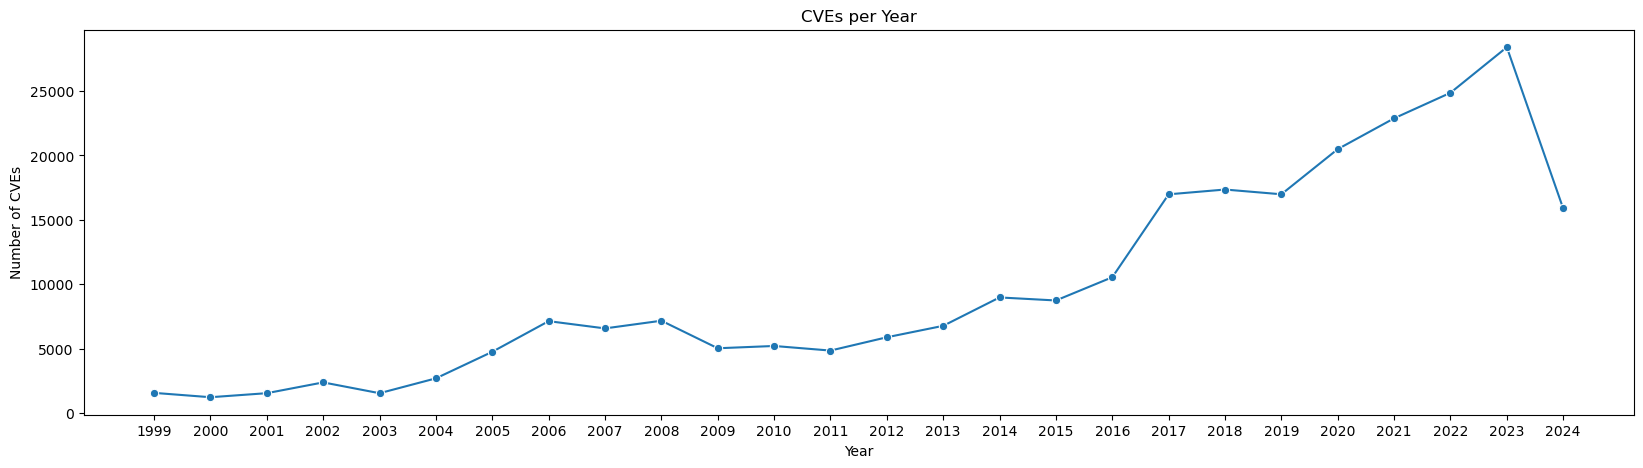

In [5]:
# Extract year from CVE ID
df_temp = df

# Extract the year from the CVE identifier
df_temp['year'] = df_temp['cve_id'].str.split('-').str[1]

# Convert to integer if necessary
df_temp['year'] = df_temp['year'].astype(int)

# Remove specified columns
df_temp = df_temp.drop(columns=['attack_technique', 'similarity', 'attack_mitigation', 'defend_tactic', 'defend_technique'])

# Remove duplicate entries based on CVE ID, keeping the first occurrence
df_cve_agg = df_temp.drop_duplicates(subset=['cve_id'])

years = list(range(df_cve_agg['year'].min(), df_cve_agg['year'].max() + 1))
cves_per_year = df_cve_agg['year'].value_counts().reindex(years, fill_value=0).sort_index()
plt.figure(figsize=(20, 5))
sns.lineplot(x=cves_per_year.index, y=cves_per_year.values, marker='o')
plt.title('CVEs per Year')
plt.xlabel('Year')
plt.ylabel('Number of CVEs')
plt.xticks(cves_per_year.index)
plt.show()

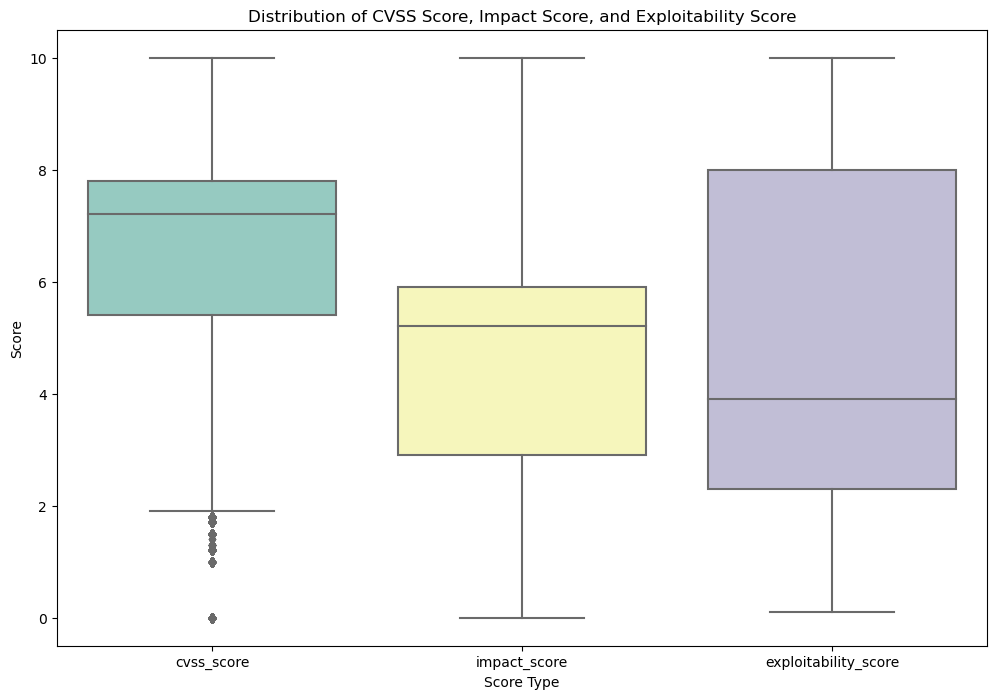

In [6]:
# Plot 4: Box plot showing the CVSS score, impact score, and exploitability score
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[['cvss_score', 'impact_score', 'exploitability_score']], palette='Set3')
plt.title('Distribution of CVSS Score, Impact Score, and Exploitability Score')
plt.xlabel('Score Type')
plt.ylabel('Score')
plt.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

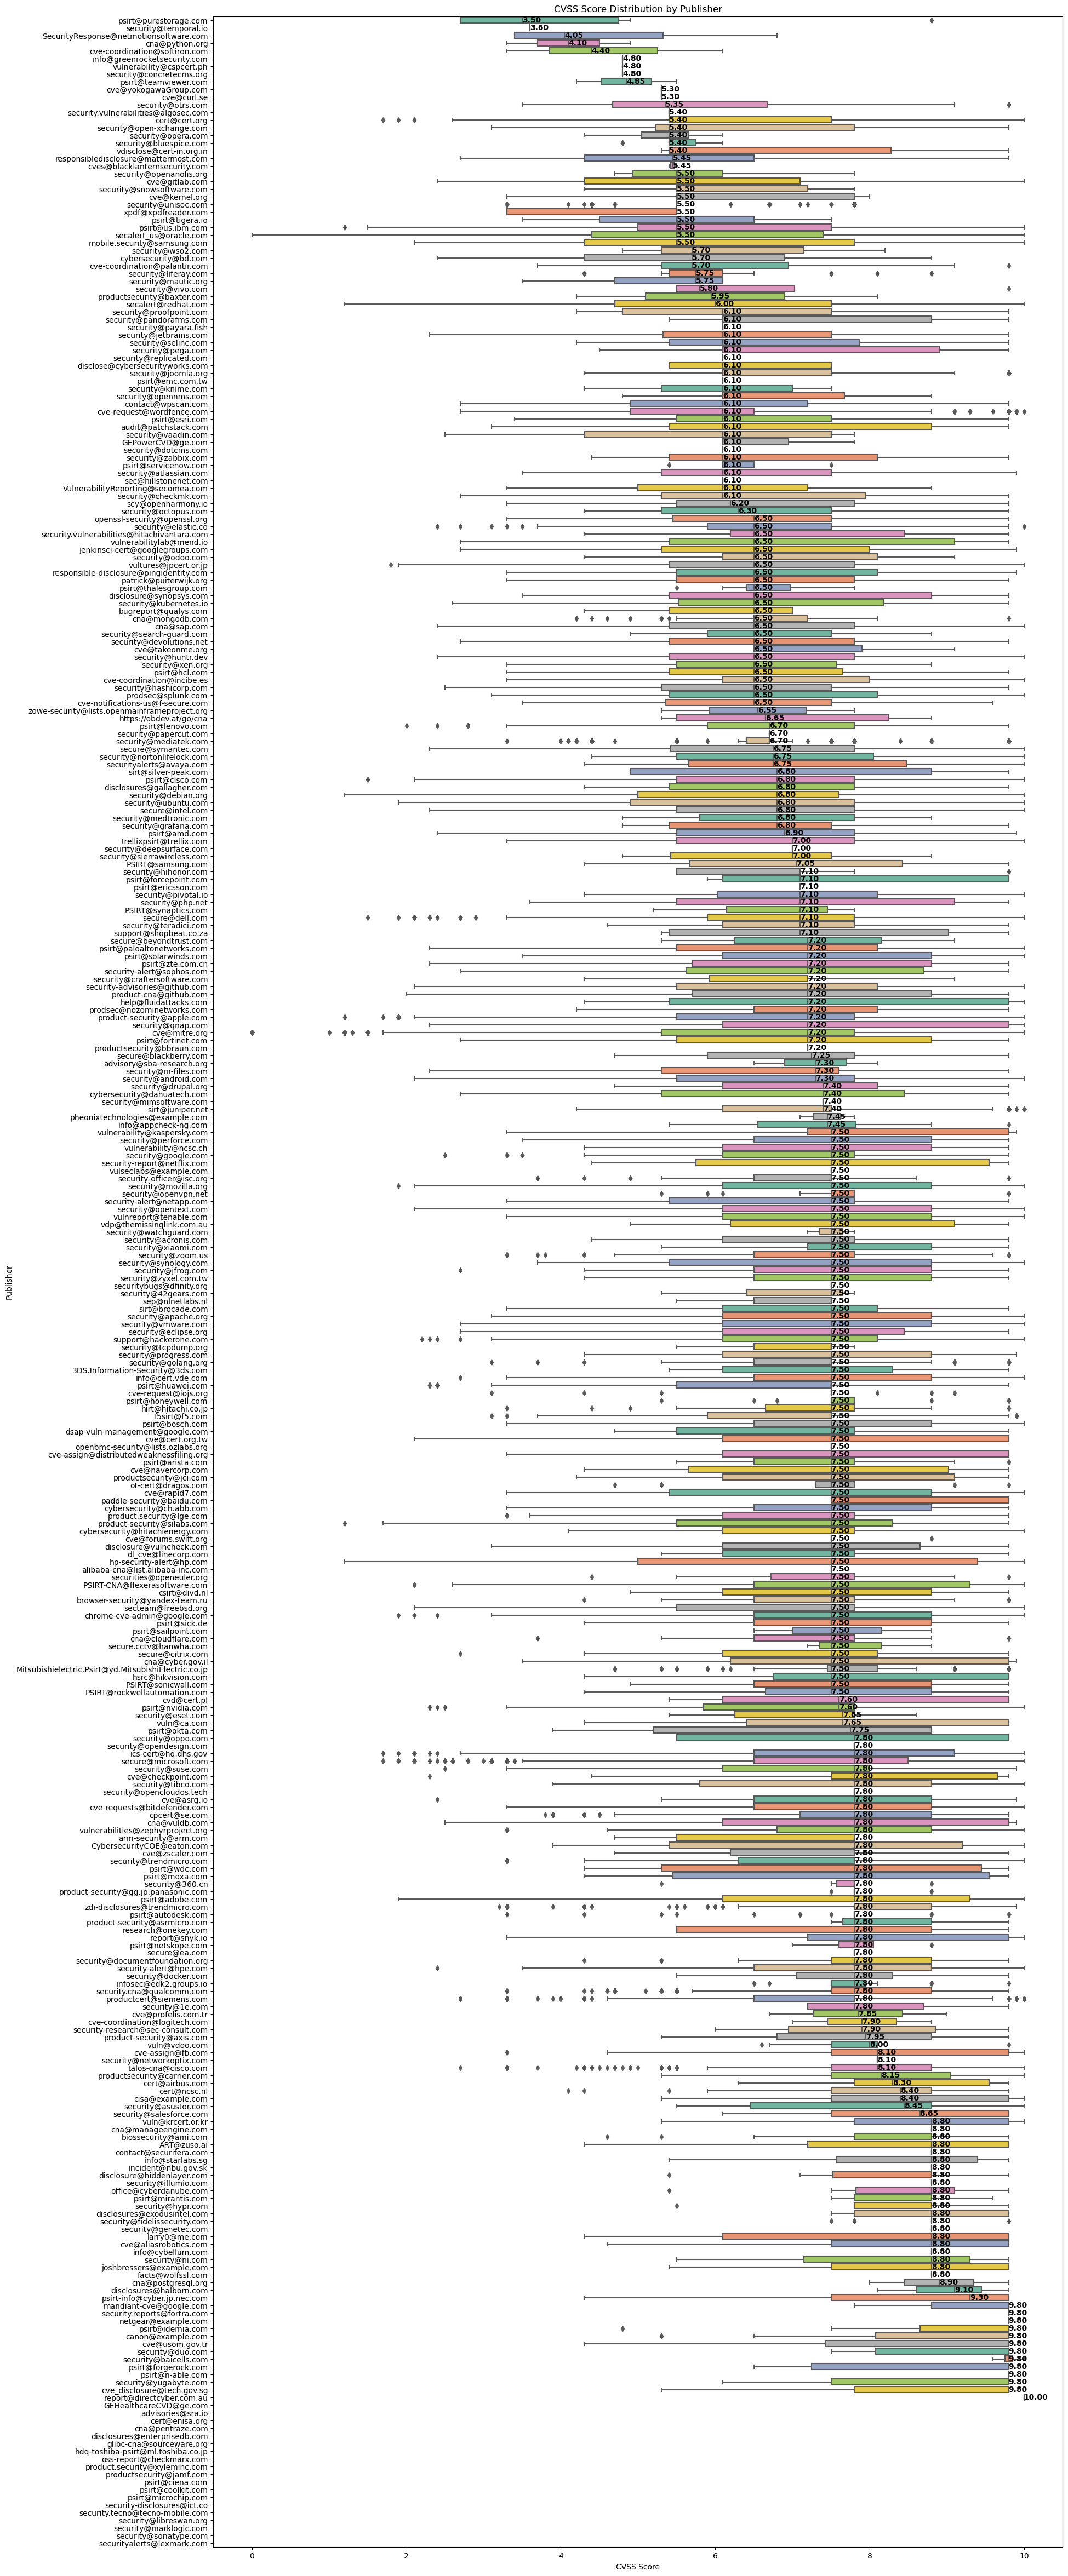

In [7]:
medians = df_cve_agg.groupby('publisher')['cvss_score'].median().sort_values()
plt.figure(figsize=(20, 60))
sns.boxplot(data=df_cve_agg, x='cvss_score', y='publisher', palette='Set2', order=medians.index)
plt.title('CVSS Score Distribution by Publisher')
plt.xlabel('CVSS Score')
plt.ylabel('Publisher')

# Adding median values as labels
for i in range(len(medians)):
    plt.text(medians[i], i, f'{medians[i]:.2f}', va='center', ha='left', color='black', fontweight='bold')

plt.show()

## A.3 Findings


### A.3.1 ATT&CK tactics found in CVE and their kill chain phases

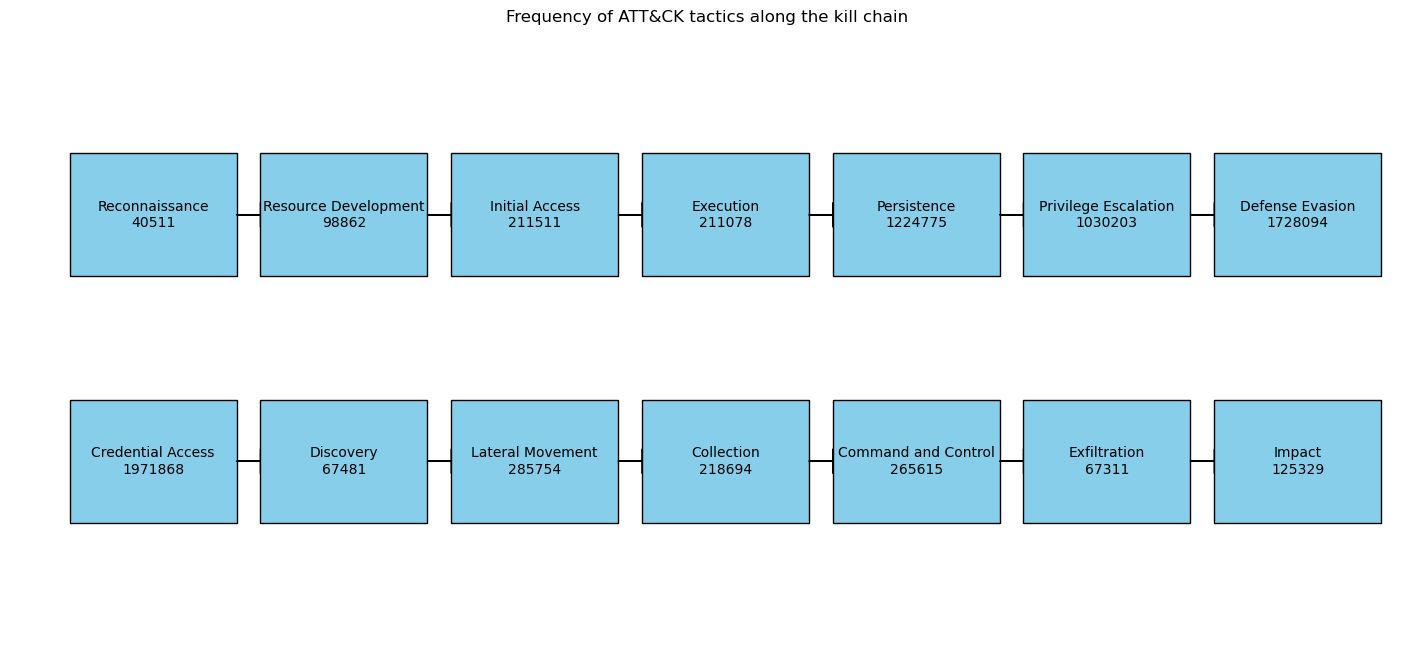

In [8]:
# Step 1: Ensure attack_tactic column contains valid lists
df['attack_tactic'] = df['attack_tactic'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Drop rows with NaN in attack_tactic
df_non_null = df.dropna(subset=['attack_tactic'])

# Step 3: Explode the list of attack_tactic into separate rows
df_exploded = df_non_null.explode('attack_tactic')

# Step 4: Create the mapping between dataset format and the ATT&CK kill chain
tactic_mapping = {
    'reconnaissance': 'Reconnaissance',
    'resource-development': 'Resource Development',
    'initial-access': 'Initial Access',
    'execution': 'Execution',
    'persistence': 'Persistence',
    'privilege-escalation': 'Privilege Escalation',
    'defense-evasion': 'Defense Evasion',
    'credential-access': 'Credential Access',
    'discovery': 'Discovery',
    'lateral-movement': 'Lateral Movement',
    'collection': 'Collection',
    'command-and-control': 'Command and Control',
    'exfiltration': 'Exfiltration',
    'impact': 'Impact'
}

# Step 5: Translate the attack_tactic values using the mapping
df_exploded['attack_tactic_translated'] = df_exploded['attack_tactic'].map(tactic_mapping)

# Step 6: Define the kill chain phases in the correct order
kill_chain_phases = [
    'Reconnaissance', 'Resource Development', 'Initial Access', 'Execution',
    'Persistence', 'Privilege Escalation', 'Defense Evasion', 'Credential Access',
    'Discovery', 'Lateral Movement', 'Collection', 'Command and Control',
    'Exfiltration', 'Impact'
]

# Step 7: Count the occurrences of each translated tactic
tactic_counts_translated = df_exploded['attack_tactic_translated'].value_counts().reindex(kill_chain_phases).fillna(0)

# Step 8: Plot the kill chain diagram with 7 blocks per row
fig, ax = plt.subplots(figsize=(18, 8))

# Function to create boxes for phases
def create_boxes(ax, phases, y_base, box_height):
    box_width = 1.4
    margin = 0.2  # Margin between boxes
    positions = np.arange(len(phases)) * (box_width + margin)
    
    for i, (phase, count) in enumerate(phases.items()):
        # Create a rectangle for each kill chain phase
        rect = patches.Rectangle((positions[i], y_base), box_width, box_height,
                                 edgecolor='black', facecolor='skyblue')
        ax.add_patch(rect)
        
        # Add the phase label and count in the middle of the box
        plt.text(positions[i] + box_width / 2, y_base + box_height / 2, f'{phase}\n{int(count)}', 
                 horizontalalignment='center', verticalalignment='center', fontsize=10)
        
        # Add directed edges (arrows) between the boxes except the last one
        if i < len(phases) - 1:
            ax.arrow(positions[i] + box_width, y_base + box_height / 2, margin, 0, 
                     head_width=0.1, head_length=0.1, fc='black', ec='black')

# Divide the phases into two rows
row_1_phases = {phase: tactic_counts_translated[phase] for phase in kill_chain_phases[:7]}
row_2_phases = {phase: tactic_counts_translated[phase] for phase in kill_chain_phases[7:]}

# Draw the boxes for the first row (7 boxes)
create_boxes(ax, row_1_phases, y_base=1.5, box_height=0.5)

# Draw the boxes for the second row (7 boxes)
create_boxes(ax, row_2_phases, y_base=0.5, box_height=0.5)

# Set limits for the axes
ax.set_xlim(-0.5, 7 * (1.4 + 0.2))  # 7 boxes per row
ax.set_ylim(0, 2.5)

# Remove axes and ticks
ax.axis('off')

# Display the kill chain diagram
plt.title('Frequency of ATT&CK tactics along the kill chain')
plt.show()


### A.3.1 ATT&CK techniques found in CVEs

In [9]:
# Step 6: Prepare data for the Sankey diagram
# We need source (tactics) and target (techniques) with their corresponding counts
tactic_technique_pairs = df_exploded.groupby(['attack_tactic_translated', 'attack_technique']).size().reset_index(name='count')

# Step 7: Create lists for Sankey diagram inputs (nodes and links)
tactics = tactic_technique_pairs['attack_tactic_translated'].unique()
techniques = tactic_technique_pairs['attack_technique'].unique()

# Step 6.1: Print the top 10 most frequent attack techniques
top_techniques = tactic_technique_pairs.groupby('attack_technique')['count'].sum().nlargest(10)
print("Top 10 Most Frequent ATT&CK Techniques:")
print(top_techniques)

# Combine tactics and techniques to create unique nodes
all_nodes = list(tactics) + list(techniques)

# Map each tactic and technique to a node index
node_map = {node: i for i, node in enumerate(all_nodes)}

# Define the source, target, and value for the links in the Sankey diagram
sources = [node_map[tactic] for tactic in tactic_technique_pairs['attack_tactic_translated']]
targets = [node_map[technique] for technique in tactic_technique_pairs['attack_technique']]
values = tactic_technique_pairs['count'].tolist()

# Step 8: Create the Sankey diagram with increased height
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes
    ),
    link=dict(
        source=sources,  # Indices of the source nodes (tactics)
        target=targets,  # Indices of the target nodes (techniques)
        value=values     # Corresponding flow value (count of occurrences)
    )
))

# Step 9: Display the Sankey diagram with increased height
fig.update_layout(
    title_text="ATT&CK tactics and their absolute distribution on ATT&CK techniques in CVE data.",
    font_size=10,
    height=10000  # Increased height for a larger diagram
)
fig.show()

Top 10 Most Frequent ATT&CK Techniques:
attack_technique
T1556        630306
T1550        305564
T1068        184210
T1556.006    181734
T1552        175500
T1659        158862
T1556.003    140508
T1223        124608
T1557.002    119352
T1078        114608
Name: count, dtype: int64


### A.3.3 ATT&CK technique distribution within CVEs over the years

In [10]:
import pandas as pd
import numpy as np
import plotly.express as px
import ast

# Assume the dataframe 'df' is already loaded and prepared

# Step 1: Check and ensure attack_tactic column contains lists
def ensure_list_format(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return x  # Return as-is if it's already a valid string or list
    elif isinstance(x, list):
        return x  # Return as-is if it's already a list
    else:
        return np.nan  # Set invalid values to NaN

df['attack_tactic'] = df['attack_tactic'].apply(ensure_list_format)

# Step 2: Drop rows with NaN in attack_tactic and make a copy to avoid the SettingWithCopyWarning
df_non_null = df.dropna(subset=['attack_tactic']).copy()

# Step 3: Extract the year from the published_date column using .loc[] to avoid the warning
df_non_null.loc[:, 'published_year'] = pd.to_datetime(df_non_null['published_date']).dt.year

# Step 4: Explode the attack_tactic list into separate rows to count each tactic per year
df_exploded = df_non_null.explode('attack_tactic')

# Step 4: Create the mapping between dataset format and the ATT&CK kill chain
tactic_mapping = {
    'reconnaissance': 'Reconnaissance',
    'resource-development': 'Resource Development',
    'initial-access': 'Initial Access',
    'execution': 'Execution',
    'persistence': 'Persistence',
    'privilege-escalation': 'Privilege Escalation',
    'defense-evasion': 'Defense Evasion',
    'credential-access': 'Credential Access',
    'discovery': 'Discovery',
    'lateral-movement': 'Lateral Movement',
    'collection': 'Collection',
    'command-and-control': 'Command and Control',
    'exfiltration': 'Exfiltration',
    'impact': 'Impact'
}

# Step 5: Translate the attack_tactic values using the mapping and filter only mapped values
df_exploded['attack_tactic_translated'] = df_exploded['attack_tactic'].map(tactic_mapping)
df_exploded = df_exploded.dropna(subset=['attack_tactic_translated'])

# Step 6: Group the data by year and translated attack_tactic, and count occurrences
tactic_by_year = df_exploded.groupby(['published_year', 'attack_tactic_translated']).size().reset_index(name='count')

# Step 7: Pivot the data so that each column represents an attack tactic, and each row represents a year
pivot_tactic_year = tactic_by_year.pivot(index='published_year', columns='attack_tactic_translated', values='count').fillna(0)

# Step 8: Normalize the data by year to calculate the relative amount of each attack tactic
pivot_tactic_year_normalized = pivot_tactic_year.div(pivot_tactic_year.sum(axis=1), axis=0).fillna(0)

# Step 9: Plot a Streamgraph using Plotly with distinct colors for each tactic
color_discrete_map = {
    'Reconnaissance': '#1f77b4',
    'Resource Development': '#ff7f0e',
    'Initial Access': '#2ca02c',
    'Execution': '#d62728',
    'Persistence': '#9467bd',
    'Privilege Escalation': '#8c564b',
    'Defense Evasion': '#e377c2',
    'Credential Access': '#7f7f7f',
    'Discovery': '#bcbd22',
    'Lateral Movement': '#17becf',
    'Collection': '#9edae5',
    'Command and Control': '#e7969c',
    'Exfiltration': '#e6f69c',
    'Impact': '#ffbb78'
}

fig = px.area(
    pivot_tactic_year_normalized,
    x=pivot_tactic_year_normalized.index,
    y=pivot_tactic_year_normalized.columns,
    title="Relative amount of ATT&CK tactics over time.",
    labels={"value": "Relative Frequency", "published_year": "Publishing year of CVEs", "attack_tactic_translated": "ATT&CK tactic"},
    color_discrete_map=color_discrete_map
)

# Display the Streamgraph
fig.show()


### A.3.4 Co-occurence of ATT&CK tactics

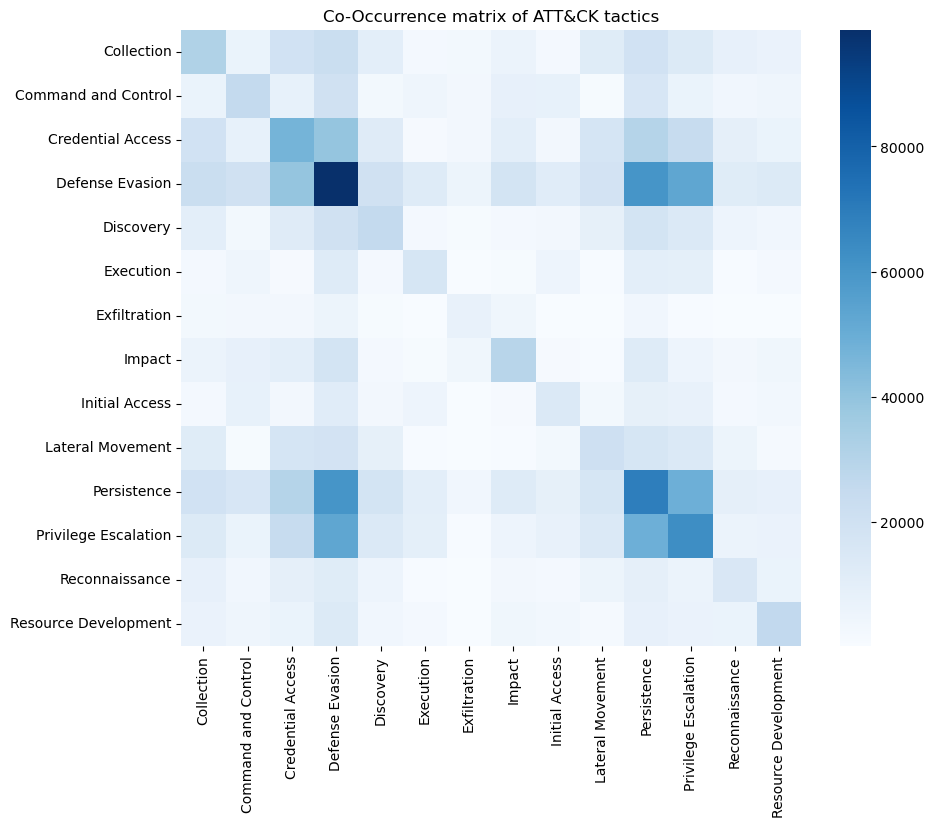

In [18]:
# Step 2: Filter out NaN values from 'attack_tactic' and ensure all values are lists
df_filtered = df.dropna(subset=['attack_tactic']).copy()  # Make a copy to avoid SettingWithCopyWarning
df_filtered.loc[:, 'attack_tactic'] = df_filtered['attack_tactic'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 3: Translate attack tactics using the mapping and filter only mapped values
def translate_tactics(tactics):
    # Use tactic_mapping to translate each tactic
    return [tactic_mapping[t] for t in tactics if t in tactic_mapping]

df_filtered.loc[:, 'attack_tactic'] = df_filtered['attack_tactic'].apply(translate_tactics)

# Step 4: Remove rows where no valid tactics are left after mapping
df_filtered = df_filtered[df_filtered['attack_tactic'].apply(lambda x: len(x) > 0)]

# Step 5: Grouping by CVE ID and converting attack tactics into a list
# Flatten any nested lists (in case of double nesting)
def flatten(tactic_list):
    return [item for sublist in tactic_list for item in sublist] if isinstance(tactic_list[0], list) else tactic_list

co_occurrence = df_filtered.groupby('cve_id')['attack_tactic'].apply(lambda x: flatten(list(x)))

# Step 6: MultiLabelBinarizer transformation to create binary matrix for attack tactics
mlb = MultiLabelBinarizer()

# Use tqdm to monitor the transformation process
binary_matrix = pd.DataFrame(mlb.fit_transform(co_occurrence), columns=mlb.classes_, index=co_occurrence.index)

# Step 7: Create co-occurrence matrix (how often tactics occur together)
co_occurrence_matrix = binary_matrix.T.dot(binary_matrix)

# Visualize the co-occurrence matrix
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, cmap="Blues", annot=False)
plt.title('Co-Occurrence matrix of ATT&CK tactics')
plt.show()

In [39]:
import pandas as pd
import ast

# Assuming 'df' is your original DataFrame that contains 'cve_id' and 'attack_tactic' columns

# Step 1: Ensure 'attack_tactic' is a list (if it's stored as a string in some cases)
df['attack_tactic'] = df['attack_tactic'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Drop rows where 'attack_tactic' is NaN or invalid (e.g., not a list)
df_non_null = df.dropna(subset=['attack_tactic'])

# Step 3: Aggregate attack tactics by CVE ID
df_aggregated = df_non_null.groupby('cve_id')['attack_tactic'].agg(lambda x: [item for sublist in x for item in sublist]).reset_index()

# Step 4: Filter CVEs based on the number of unique tactics
df_aggregated['unique_tactics'] = df_aggregated['attack_tactic'].apply(lambda tactics: len(set(tactics)))  # Count unique tactics

# Step 5: Calculate the number and percentage of CVEs with 1 to 14 unique tactics
total_cves = df_aggregated['cve_id'].nunique()

single_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 1]['cve_id'].nunique()
two_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 2]['cve_id'].nunique()
three_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 3]['cve_id'].nunique()
four_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 4]['cve_id'].nunique()
five_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 5]['cve_id'].nunique()
six_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 6]['cve_id'].nunique()
seven_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 7]['cve_id'].nunique()
eight_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 8]['cve_id'].nunique()
nine_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 9]['cve_id'].nunique()
ten_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 10]['cve_id'].nunique()
eleven_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 11]['cve_id'].nunique()
twelve_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 12]['cve_id'].nunique()
thirteen_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 13]['cve_id'].nunique()
fourteen_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 14]['cve_id'].nunique()

# Calculate percentages
percentage_single_tactic = (single_tactic_cves / total_cves) * 100
percentage_two_tactic = (two_tactic_cves / total_cves) * 100
percentage_three_tactic = (three_tactic_cves / total_cves) * 100
percentage_four_tactic = (four_tactic_cves / total_cves) * 100
percentage_five_tactic = (five_tactic_cves / total_cves) * 100
percentage_six_tactic = (six_tactic_cves / total_cves) * 100
percentage_seven_tactic = (seven_tactic_cves / total_cves) * 100
percentage_eight_tactic = (eight_tactic_cves / total_cves) * 100
percentage_nine_tactic = (nine_tactic_cves / total_cves) * 100
percentage_ten_tactic = (ten_tactic_cves / total_cves) * 100
percentage_eleven_tactic = (eleven_tactic_cves / total_cves) * 100
percentage_twelve_tactic = (twelve_tactic_cves / total_cves) * 100
percentage_thirteen_tactic = (thirteen_tactic_cves / total_cves) * 100
percentage_fourteen_tactic = (fourteen_tactic_cves / total_cves) * 100

# Step 6: Display the results
print(f"CVEs with only one unique tactic: {single_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with one unique tactic: {percentage_single_tactic:.2f}%")

print(f"CVEs with two unique tactics: {two_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with two unique tactics: {percentage_two_tactic:.2f}%")

print(f"CVEs with three unique tactics: {three_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with three unique tactics: {percentage_three_tactic:.2f}%")

print(f"CVEs with four unique tactics: {four_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with four unique tactics: {percentage_four_tactic:.2f}%")

print(f"CVEs with five unique tactics: {five_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with five unique tactics: {percentage_five_tactic:.2f}%")

print(f"CVEs with six unique tactics: {six_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with six unique tactics: {percentage_six_tactic:.2f}%")

print(f"CVEs with seven unique tactics: {seven_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with seven unique tactics: {percentage_seven_tactic:.2f}%")

print(f"CVEs with eight unique tactics: {eight_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with eight unique tactics: {percentage_eight_tactic:.2f}%")

print(f"CVEs with nine unique tactics: {nine_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with nine unique tactics: {percentage_nine_tactic:.2f}%")

print(f"CVEs with ten unique tactics: {ten_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with ten unique tactics: {percentage_ten_tactic:.2f}%")

print(f"CVEs with eleven unique tactics: {eleven_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with eleven unique tactics: {percentage_eleven_tactic:.2f}%")

print(f"CVEs with twelve unique tactics: {twelve_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with twelve unique tactics: {percentage_twelve_tactic:.2f}%")

print(f"CVEs with thirteen unique tactics: {thirteen_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with thirteen unique tactics: {percentage_thirteen_tactic:.2f}%")

print(f"CVEs with fourteen unique tactics: {fourteen_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with fourteen unique tactics: {percentage_fourteen_tactic:.2f}%")

# Optionally, save the results to a file
# df_aggregated.to_csv("cves_with_tactic_counts.csv", index=False)


CVEs with only one unique tactic: 35349 out of 152329 CVEs
Percentage of CVEs with one unique tactic: 23.21%
CVEs with two unique tactics: 27709 out of 152329 CVEs
Percentage of CVEs with two unique tactics: 18.19%
CVEs with three unique tactics: 27523 out of 152329 CVEs
Percentage of CVEs with three unique tactics: 18.07%
CVEs with four unique tactics: 19928 out of 152329 CVEs
Percentage of CVEs with four unique tactics: 13.08%
CVEs with five unique tactics: 13056 out of 152329 CVEs
Percentage of CVEs with five unique tactics: 8.57%
CVEs with six unique tactics: 12478 out of 152329 CVEs
Percentage of CVEs with six unique tactics: 8.19%
CVEs with seven unique tactics: 6399 out of 152329 CVEs
Percentage of CVEs with seven unique tactics: 4.20%
CVEs with eight unique tactics: 4690 out of 152329 CVEs
Percentage of CVEs with eight unique tactics: 3.08%
CVEs with nine unique tactics: 3640 out of 152329 CVEs
Percentage of CVEs with nine unique tactics: 2.39%
CVEs with ten unique tactics: 946

In [22]:

# Step 5: Perform logistic regression for each tactic pair to analyze co-occurrence
regression_results = {}

# Use tqdm to monitor regression progress

for tactic in tqdm(binary_matrix.columns):
    y = binary_matrix[tactic]  # Dependent variable: presence of this tactic
    
    # Independent variables: presence of other tactics
    X = binary_matrix.drop(columns=[tactic])  # Exclude the current tactic from independent variables
    X = sm.add_constant(X)  # Add a constant term for the intercept
    
    # Perform logistic regression
    model = sm.Logit(y, X)
    result = model.fit(disp=0)  # Suppress output
    
    # Store the summary of the regression result
    regression_results[tactic] = result.summary()

# Display regression summaries for each attack tactic
for tactic, summary in regression_results.items():
    print(f"--- Regression Results for {tactic} ---")
    print(summary)
    print("\n")

Performing logistic regression for each attack tactic...


100%|███████████████████████████████████████████| 14/14 [00:07<00:00,  1.76it/s]

--- Regression Results for Collection ---
                           Logit Regression Results                           
Dep. Variable:             Collection   No. Observations:               150858
Model:                          Logit   Df Residuals:                   150844
Method:                           MLE   Df Model:                           13
Date:                Tue, 17 Sep 2024   Pseudo R-squ.:                  0.2124
Time:                        08:52:20   Log-Likelihood:                -60936.
converged:                       True   LL-Null:                       -77368.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.2856      0.015   -149.149      0.000      -2.316      -2.256
Command and Control      0.5079      0.021     23.797      

In [29]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from tqdm import tqdm

def create_aggregated_latex_table(binary_matrix, regression_results):
    """
    This function performs logistic regressions on each attack tactic and creates an aggregated
    table of regression coefficients. It then outputs the table in LaTeX format with rotated column names,
    and uses top, mid, and bottom rules for better formatting.
    
    Parameters:
    - binary_matrix: pandas DataFrame with binary data for each tactic (1 if the tactic is present, 0 if not).
    - regression_results: a dictionary to store logistic regression results for each tactic.

    Returns:
    - LaTeX code for the aggregated table with rotated column names and formatted coefficients.
    """
    # Create an empty DataFrame to store the coefficients from each logistic regression model
    aggregated_table = pd.DataFrame(index=binary_matrix.columns, columns=binary_matrix.columns)

    # Loop through each tactic and perform logistic regression
    for tactic in tqdm(binary_matrix.columns):
        y = binary_matrix[tactic]  # Dependent variable: presence of this tactic
        X = binary_matrix.drop(columns=[tactic])  # Exclude the current tactic from independent variables
        X = sm.add_constant(X)  # Add a constant term for the intercept

        # Perform logistic regression
        model = sm.Logit(y, X)
        result = model.fit(disp=0)  # Suppress output
        
        # Extract the coefficients from the result
        coef = result.params
        
        # Store the coefficients in the aggregated table (fill NaN for the current dependent variable)
        for predictor in coef.index:
            if predictor == "const":
                continue
            aggregated_table.at[tactic, predictor] = coef[predictor]

    # Replace NaN values with "-"
    aggregated_table = aggregated_table.fillna("-")
    
    # Create LaTeX code for the table
    latex_code = "\\begin{table*}[ht]\n\\centering\n\\resizebox{\\textwidth}{!}{%\n"
    latex_code += "\\begin{tabular}{l" + "r" * len(binary_matrix.columns) + "}\n"
    
    # Add header with rotated column names
    latex_code += "\\toprule\n"
    latex_code += "& " + " & ".join([f"\\rotatebox{{70}}{{{col}}}" for col in binary_matrix.columns]) + " \\\\\n"
    latex_code += "\\midrule\n"
    
    # Add each row
    for index, row in aggregated_table.iterrows():
        latex_code += f"{index} & "
        
        # Identify the maximum value in the row (ignoring "-")
        numeric_values = row.apply(lambda x: x if x != "-" else np.nan)
        max_value = numeric_values.max()
        
        for col in binary_matrix.columns:
            value = row[col]
            if value == "-":
                latex_code += "- & "
            else:
                # Format coefficient (four decimal places without removing the leading zero)
                formatted_value = f"{value:.4f}"  # Shorten to 4 decimal places
                
                # Apply bold formatting if the value is the maximum in the row
                if value == max_value:
                    latex_code += f"\\textbf{{{formatted_value}}} & "
                else:
                    latex_code += f"{formatted_value} & "
                    
        latex_code = latex_code.rstrip(" & ")  # Remove trailing "&" for each row
        latex_code += " \\\\\n"
    
    latex_code += "\\bottomrule\n"
    latex_code += "\\end{tabular}}\n\\caption{Logistic Regression Coefficients for Tactic Co-Occurrence.}\n"
    latex_code += "\\label{tab:logistic_regression}\n\\end{table*}"

    # Return the LaTeX code for the table
    return latex_code

# Usage Example
latex_table = create_aggregated_latex_table(binary_matrix, regression_results)

# To view the LaTeX table:
print(latex_table)


100%|███████████████████████████████████████████| 14/14 [00:04<00:00,  3.47it/s]

\begin{table*}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrrrrrrrrrr}
\toprule
& \rotatebox{70}{Collection} & \rotatebox{70}{Command and Control} & \rotatebox{70}{Credential Access} & \rotatebox{70}{Defense Evasion} & \rotatebox{70}{Discovery} & \rotatebox{70}{Execution} & \rotatebox{70}{Exfiltration} & \rotatebox{70}{Impact} & \rotatebox{70}{Initial Access} & \rotatebox{70}{Lateral Movement} & \rotatebox{70}{Persistence} & \rotatebox{70}{Privilege Escalation} & \rotatebox{70}{Reconnaissance} & \rotatebox{70}{Resource Development} \\
\midrule
Collection & - & 0.5079 & 1.0375 & -0.4054 & 0.7342 & 0.2632 & 0.9857 & -0.0966 & -0.7986 & \textbf{1.5245} & 0.3540 & -0.4431 & 1.1767 & 0.4447 \\
Command and Control & 0.6289 & - & 0.0283 & 0.5715 & -0.8317 & -0.0210 & 0.8166 & 0.4613 & \textbf{2.9583} & -1.7873 & 1.6942 & -1.9417 & 0.2991 & 0.0893 \\
Credential Access & 1.0696 & 0.1474 & - & 0.9752 & 0.0577 & -1.1674 & 0.1436 & 0.4124 & -1.1631 & \textbf{2.3981} & 0.3465 & 

# PART B: Analyzing the defenders' playbooks

@Daniel

# PART C: Contrasting attackers and defenders
@Johannes